# SVM: startup outcome prediction

Uses `cleaned_startup_data.csv` from the corrected EDA notebook. Closed = 0; acquired = 1. Operating and IPO companies are excluded to preserve the original binary task. This is a historical acquired-versus-closed classifier, not a validated forecast of survival duration.

Both models use the same seven features, stratified 80/20 split (seed 42), and three training-only cross-validation folds. Macro F1 is the selection metric because both outcomes matter. Baseline cross-validation is followed by six hyperparameter candidates per model. The held-out test set is used only after tuning.

In [1]:
from pathlib import Path
from time import perf_counter
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

model_name = "SVM"
result_name = "svm"
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

## Load and split

Funding uses `log1p` to reduce its skew; this fixed transformation learns nothing from the data. Missing values are filled within the pipeline after splitting. IDs and labels are excluded from features. Rows are sorted by startup ID so the shared split is reproducible.

In [2]:
df = pd.read_csv("cleaned_startup_data.csv").sort_values("startup_id").reset_index(drop=True)
assert df["startup_id"].notna().all() and df["startup_id"].is_unique
assert df["target"].isin([0, 1]).all()

numeric_columns = [
    "funding_total_usd", "funding_rounds", "founded_at_year",
    "first_funding_at_year", "last_funding_at_year"
]
categorical_columns = ["country_code", "first_category"]
X = df[numeric_columns + categorical_columns].copy()
X["funding_total_usd"] = np.log1p(X["funding_total_usd"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
assert set(X_train.index).isdisjoint(X_test.index)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
split_counts = pd.DataFrame({
    "Train": y_train.value_counts(), "Test": y_test.value_counts()
}).rename(index={0: "Closed", 1: "Acquired"})
display(split_counts)
print("Training rows:", len(X_train), "Test rows:", len(X_test))

,Train,Test
target,,
Closed,4990,1248
Acquired,4439,1110


Training rows: 9429 Test rows: 2358


## Preprocessing and model

Numeric values use training-fold medians. Categorical missing values become `Unknown`, then one-hot encoding groups categories occurring fewer than 20 times in that training fold. Unseen categories are handled during prediction. SVM additionally standardizes numeric features; trees do not need scaling. All learned preprocessing is fitted again within each cross-validation fold.

In [3]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_columns),
    ("categorical", categorical_transformer, categorical_columns)
])
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale"))
])
scoring = {
    "accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
    "precision": "precision", "recall": "recall", "f1": "f1",
    "f1_macro": "f1_macro", "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

## Baseline cross-validation

In [4]:
baseline_scores = cross_validate(
    model, X_train, y_train, cv=cv, scoring=scoring,
    n_jobs=1, error_score="raise"
)
baseline_summary = pd.DataFrame({
    "mean": {metric: baseline_scores["test_" + metric].mean() for metric in scoring},
    "std": {metric: baseline_scores["test_" + metric].std() for metric in scoring}
})
display(baseline_summary.round(4))

,mean,std
accuracy,0.7265,0.0094
balanced_accuracy,0.7256,0.0091
precision,0.7097,0.0139
recall,0.7098,0.0143
f1,0.7096,0.0091
f1_macro,0.7255,0.0093
roc_auc,0.7996,0.0073
average_precision,0.7520,0.0019


## Small hyperparameter search

Each algorithm receives six candidates and the same three folds. The default starting configuration is included in its grid. Select by mean validation macro F1, then refit the selected pipeline on all training rows. Search scores are selection estimates and may be optimistic; the holdout provides a separate assessment. Fold standard deviations are not confidence intervals.

In [5]:
parameter_grid = {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.1]}
search = GridSearchCV(
    model, parameter_grid, scoring=scoring, refit="f1_macro",
    cv=cv, n_jobs=1, error_score="raise", return_train_score=True
)
start = perf_counter()
search.fit(X_train, y_train)
search_seconds = perf_counter() - start
best_model = search.best_estimator_
print("Best parameters:", search.best_params_)
print("Best validation macro F1:", round(search.best_score_, 4))
print("Search time in seconds:", round(search_seconds, 2))

cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_f1_macro")
cv_results.to_csv(results_dir / f"{result_name}_search.csv", index=False)
display(cv_results[[
    "params", "mean_train_f1_macro", "mean_test_f1_macro",
    "std_test_f1_macro", "mean_test_roc_auc", "mean_fit_time"
]].round(4))

cv_summary = baseline_summary.rename(columns={"mean": "baseline_mean", "std": "baseline_std"})
cv_summary["tuned_mean"] = [search.cv_results_["mean_test_" + metric][search.best_index_] for metric in scoring]
cv_summary["tuned_std"] = [search.cv_results_["std_test_" + metric][search.best_index_] for metric in scoring]
cv_summary.index.name = "metric"
cv_summary.to_csv(results_dir / f"{result_name}_cv.csv")
display(cv_summary.round(4))

Best parameters: {'model__C': 1, 'model__gamma': 0.1}
Best validation macro F1: 0.7263
Search time in seconds: 76.82


,params,mean_train_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_test_roc_auc,mean_fit_time
3,"{'model__C': 1, 'model__gamma': 0.1}",0.7593,0.7263,0.0083,0.8000,1.3762
2,"{'model__C': 1, 'model__gamma': 'scale'}",0.7600,0.7255,0.0093,0.7996,1.3979
0,"{'model__C': 0.1, 'model__gamma': 'scale'}",0.7255,0.7166,0.0026,0.7916,1.3229
1,"{'model__C': 0.1, 'model__gamma': 0.1}",0.7249,0.7166,0.0026,0.7918,1.4026
5,"{'model__C': 10, 'model__gamma': 0.1}",0.8124,0.7141,0.0042,0.7838,1.8295
4,"{'model__C': 10, 'model__gamma': 'scale'}",0.8149,0.7135,0.0049,0.7828,1.8989


,baseline_mean,baseline_std,tuned_mean,tuned_std
metric,,,,
accuracy,0.7265,0.0094,0.7273,0.0084
balanced_accuracy,0.7256,0.0091,0.7264,0.0082
precision,0.7097,0.0139,0.7109,0.0122
recall,0.7098,0.0143,0.7098,0.0141
f1,0.7096,0.0091,0.7102,0.0087
f1_macro,0.7255,0.0093,0.7263,0.0083
roc_auc,0.7996,0.0073,0.8000,0.0070
average_precision,0.7520,0.0019,0.7523,0.0018


## Held-out evaluation

Precision, recall, F1, ROC AUC and average precision use acquired (1) as the positive class. Macro F1 averages both classes equally. The class report separately shows closed-startup performance. Average precision summarizes the precision-recall curve. SVM curves use decision scores, which are not probabilities. The majority-class dummy provides a simple reference.

In [6]:
start = perf_counter()
y_pred = best_model.predict(X_test)
prediction_seconds = perf_counter() - start
y_score = best_model.decision_function(X_test)

def evaluate(actual, predicted, scores):
    return {
        "accuracy": accuracy_score(actual, predicted),
        "balanced_accuracy": balanced_accuracy_score(actual, predicted),
        "precision": precision_score(actual, predicted, zero_division=0),
        "recall": recall_score(actual, predicted, zero_division=0),
        "f1": f1_score(actual, predicted, zero_division=0),
        "f1_macro": f1_score(actual, predicted, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(actual, scores),
        "average_precision": average_precision_score(actual, scores)
    }

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
test_metrics = evaluate(y_test, y_pred, y_score)
dummy_metrics = evaluate(y_test, dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1])
display(pd.DataFrame([test_metrics, dummy_metrics], index=[model_name, "Majority baseline"]).round(4))
print(classification_report(y_test, y_pred, target_names=["Closed", "Acquired"], digits=4, zero_division=0))

train_pred = best_model.predict(X_train)
display(pd.DataFrame({
    "accuracy": [accuracy_score(y_train, train_pred), test_metrics["accuracy"]],
    "f1_macro": [f1_score(y_train, train_pred, average="macro"), test_metrics["f1_macro"]]
}, index=["Training", "Test"]).round(4))
print("Final training time in seconds:", round(search.refit_time_, 3))
print("Test prediction time in seconds:", round(prediction_seconds, 3))

,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,roc_auc,average_precision
SVM,0.7366,0.7353,0.7237,0.7126,0.7181,0.7355,0.8148,0.7711
Majority baseline,0.5293,0.5000,0.0000,0.0000,0.0000,0.3461,0.5000,0.4707


              precision    recall  f1-score   support

      Closed     0.7478    0.7580    0.7529      1248
    Acquired     0.7237    0.7126    0.7181      1110

    accuracy                         0.7366      2358
   macro avg     0.7358    0.7353    0.7355      2358
weighted avg     0.7365    0.7366    0.7365      2358



,accuracy,f1_macro
Training,0.7593,0.7584
Test,0.7366,0.7355


Final training time in seconds: 3.558
Test prediction time in seconds: 0.412


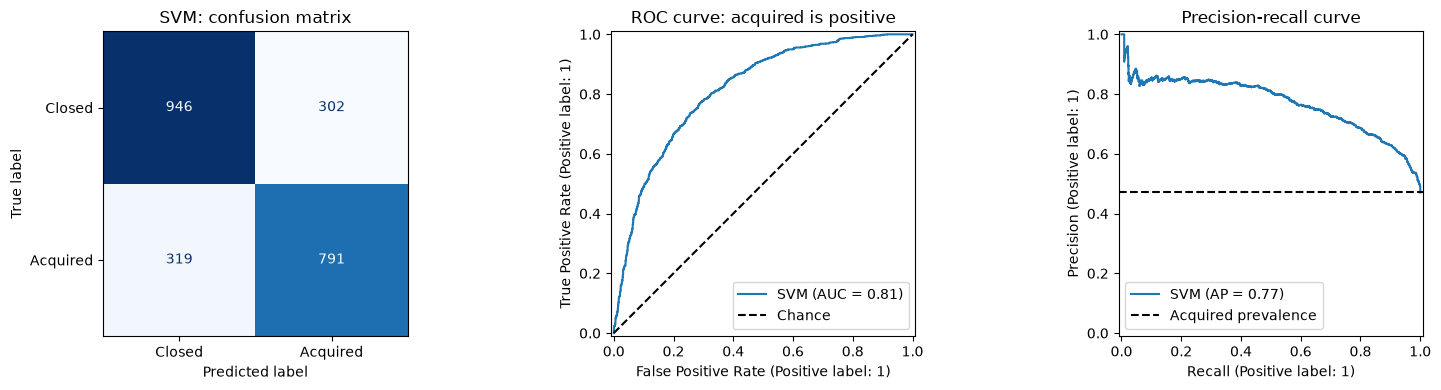

In [7]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Closed", "Acquired"],
    cmap="Blues", colorbar=False, ax=axes[0]
)
axes[0].set_title(model_name + ": confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_score, name=model_name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="Chance")
axes[1].set_title("ROC curve: acquired is positive")
axes[1].legend()
PrecisionRecallDisplay.from_predictions(y_test, y_score, name=model_name, ax=axes[2])
axes[2].axhline(y_test.mean(), color="black", linestyle="--", label="Acquired prevalence")
axes[2].set_title("Precision-recall curve")
axes[2].legend()
plt.tight_layout()
figure.savefig(results_dir / f"{result_name}_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## Save results and compare models

After both notebooks run, `model_comparison.csv` contains both results, ranked by training cross-validation macro F1. The test columns describe final holdout performance and must not guide repeated tuning. Run this last cell again to refresh the comparison after running the other notebook. Timing values are approximate wall-clock measurements on the current machine.

In [8]:
summary = {
    "model": model_name,
    "baseline_cv_f1_macro": baseline_summary.loc["f1_macro", "mean"],
    "cv_f1_macro": search.best_score_,
    "cv_f1_macro_std": search.cv_results_["std_test_f1_macro"][search.best_index_],
    **{"test_" + metric: value for metric, value in test_metrics.items()},
    "search_seconds": search_seconds,
    "refit_seconds": search.refit_time_,
    "prediction_seconds": prediction_seconds,
    "best_parameters": json.dumps(search.best_params_),
    "train_rows": len(X_train), "test_rows": len(X_test)
}
pd.DataFrame([summary]).to_csv(results_dir / f"{result_name}_metrics.csv", index=False)
pd.DataFrame({
    "startup_id": df.loc[X_test.index, "startup_id"].to_numpy(),
    "actual": y_test.to_numpy(), "predicted": y_pred, "score": y_score
}).to_csv(results_dir / f"{result_name}_predictions.csv", index=False)
pd.DataFrame(classification_report(
    y_test, y_pred, target_names=["Closed", "Acquired"],
    output_dict=True, zero_division=0
)).T.to_csv(results_dir / f"{result_name}_classification_report.csv")

metric_files = [results_dir / "random_forest_metrics.csv", results_dir / "svm_metrics.csv"]
comparison = pd.concat([pd.read_csv(path) for path in metric_files if path.exists()], ignore_index=True)
comparison = comparison.sort_values("cv_f1_macro", ascending=False)
comparison.to_csv(results_dir / "model_comparison.csv", index=False)
display(comparison[[
    "model", "baseline_cv_f1_macro", "cv_f1_macro", "cv_f1_macro_std",
    "test_accuracy", "test_precision", "test_recall", "test_f1_macro", "test_roc_auc"
]].round(4))
if len(comparison) == 2:
    print("Candidate selected by validation macro F1:", comparison.iloc[0]["model"])
else:
    print("Run the other model notebook to complete the comparison.")

,model,baseline_cv_f1_macro,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_precision,test_recall,test_f1_macro,test_roc_auc
0,Random Forest,0.7139,0.7273,0.0055,0.7426,0.7322,0.7144,0.7413,0.8266
1,SVM,0.7255,0.7263,0.0083,0.7366,0.7237,0.7126,0.7355,0.8148


Candidate selected by validation macro F1: Random Forest
